In [125]:
import os
import pandas as pd
import yfinance as yf

os.makedirs("data", exist_ok=True)

In [126]:
stocks = {
    "RELIANCE.NS": "Reliance Industries",
    "TCS.NS": "TCS",
    "INFY.NS": "Infosys",
    "HDFCBANK.NS": "HDFC Bank",
    "ICICIBANK.NS": "ICICI Bank"
}

In [127]:
def fetch_news_yfinance(stocks):
    all_news = []

    for ticker, company in stocks.items():
        print(f"Fetching news for {ticker}...")

        stock = yf.Ticker(ticker)
        news = stock.news

        if not news:
            continue

        for article in news:

            title = article.get("title")
            date = article.get("providerPublishTime")
            source = article.get("publisher")


            if not title:
                content = article.get("content", {})
                title = content.get("title")
                date = content.get("pubDate")
                source = content.get("provider", {}).get("displayName")

            all_news.append({
                "date": date,
                "title": title,
                "source": source,
                "company": company,
                "ticker": ticker
            })

    df = pd.DataFrame(all_news)
    return df

In [128]:
news_df = fetch_news_yfinance(stocks)


news_df.dropna(subset=["title"], inplace=True)

print(news_df.shape)
news_df.head()

Fetching news for RELIANCE.NS...
Fetching news for TCS.NS...
Fetching news for INFY.NS...
Fetching news for HDFCBANK.NS...
Fetching news for ICICIBANK.NS...
(50, 5)


,date,title,source,company,ticker
0,2026-04-06T14:53:53Z,India's Reliance buys Venezuelan oil directly ...,Reuters,Reliance Industries,RELIANCE.NS
1,2026-04-03T14:07:15Z,How The Investment Story For Reliance Industri...,Simply Wall St.,Reliance Industries,RELIANCE.NS
2,2026-04-01T01:51:53Z,India diesel exports to SE Asia hit 7-year hig...,Reuters,Reliance Industries,RELIANCE.NS
3,2026-03-26T12:28:31Z,OpenAI Appoints JioStar CEO to Lead Asia Expan...,GuruFocus.com,Reliance Industries,RELIANCE.NS
4,2026-03-24T10:06:43Z,Exclusive-India's Reliance buys 5 million barr...,Reuters,Reliance Industries,RELIANCE.NS


In [129]:
news_df.to_csv("data/news_data.csv", index=False)

In [130]:
stock_df = fetch_multiple_stocks(stocks)

print("Stock data shape:", stock_df.shape)
stock_df.head()

/tmp/ipykernel_3626/3582768257.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_3626/3582768257.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_3626/3582768257.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed

Fetching stock data for RELIANCE.NS...
Fetching stock data for TCS.NS...
Fetching stock data for INFY.NS...
Fetching stock data for HDFCBANK.NS...



/tmp/ipykernel_3626/3582768257.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed

Fetching stock data for ICICIBANK.NS...



/tmp/ipykernel_3626/3582768257.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed

Stock data shape: (95, 27)


Price,Date,Close,High,Low,Open,Volume,ticker,Close,High,Low,...,Close,High,Low,Open,Volume,Close,High,Low,Open,Volume
Ticker,,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,,TCS.NS,TCS.NS,TCS.NS,...,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS,ICICIBANK.NS,ICICIBANK.NS,ICICIBANK.NS,ICICIBANK.NS,ICICIBANK.NS
0,2026-03-02,1358.000000,1378.599976,1341.500000,1375.500000,23728722.0,RELIANCE.NS,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-03-04,1345.000000,1352.800049,1307.000000,1330.000000,32495007.0,RELIANCE.NS,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-03-05,1389.400024,1399.000000,1353.099976,1353.099976,25957532.0,RELIANCE.NS,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-03-06,1404.800049,1424.300049,1390.300049,1396.500000,19311971.0,RELIANCE.NS,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026-03-09,1424.000000,1429.400024,1370.000000,1375.000000,24870822.0,RELIANCE.NS,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [131]:
stock_df.to_csv("data/stock_data.csv", index=False)

In [132]:
!pip install transformers torch --quiet


import torch
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification

In [133]:
MODEL_NAME = "yiyanghkust/finbert-tone"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)

model.eval()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: yiyanghkust/finbert-tone
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30873, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [134]:
news_df = pd.read_csv("data/news_data.csv")

In [135]:
def get_sentiment_batch(text_list):
    inputs = tokenizer(
        text_list,
        return_tensors="pt",
        truncation=True,
        padding=True
    )

    with torch.no_grad():
        outputs = model(**inputs)

    scores = torch.nn.functional.softmax(outputs.logits, dim=1)


    sentiment_scores = scores[:, 2] - scores[:, 0]

    return sentiment_scores.numpy()

In [136]:

news_sample = news_df.head(100).copy()

batch_size = 16
sentiments = []

titles = news_sample["title"].tolist()

for i in range(0, len(titles), batch_size):
    batch = titles[i:i+batch_size]
    scores = get_sentiment_batch(batch)
    sentiments.extend(scores)

news_sample["sentiment"] = sentiments

news_sample.head()

,date,title,source,company,ticker,sentiment
0,2026-04-06T14:53:53Z,India's Reliance buys Venezuelan oil directly ...,Reuters,Reliance Industries,RELIANCE.NS,-0.999980
1,2026-04-03T14:07:15Z,How The Investment Story For Reliance Industri...,Simply Wall St.,Reliance Industries,RELIANCE.NS,-0.999541
2,2026-04-01T01:51:53Z,India diesel exports to SE Asia hit 7-year hig...,Reuters,Reliance Industries,RELIANCE.NS,0.996903
3,2026-03-26T12:28:31Z,OpenAI Appoints JioStar CEO to Lead Asia Expan...,GuruFocus.com,Reliance Industries,RELIANCE.NS,-0.982704
4,2026-03-24T10:06:43Z,Exclusive-India's Reliance buys 5 million barr...,Reuters,Reliance Industries,RELIANCE.NS,-0.998926


In [137]:
batch_size = 16
sentiments = []

titles = news_df["title"].tolist()

for i in range(0, len(titles), batch_size):
    batch = titles[i:i+batch_size]
    scores = get_sentiment_batch(batch)
    sentiments.extend(scores)

news_df["sentiment"] = sentiments

In [138]:
news_df.to_csv("data/news_with_sentiment.csv", index=False)

In [139]:
news_df = pd.read_csv("data/news_with_sentiment.csv")
stock_df = pd.read_csv("data/stock_data.csv")

print(news_df.shape, stock_df.shape)

(50, 6) (96, 27)


In [140]:

stock_df = stock_df.reset_index(drop=True)
stock_df = stock_df.loc[:, ~stock_df.columns.duplicated()]


news_df["date"] = pd.to_datetime(news_df["date"], errors="coerce")
stock_df["Date"] = pd.to_datetime(stock_df["Date"], errors="coerce")


news_df = news_df.dropna(subset=["date", "sentiment"])

In [141]:

news_df = news_df.sort_values("date")
stock_df = stock_df.sort_values("Date")

In [142]:
news_df = news_df.dropna(subset=["date"])
stock_df = stock_df.dropna(subset=["Date"])

In [143]:

news_df["date"] = news_df["date"].dt.tz_localize(None)


stock_df["Date"] = pd.to_datetime(stock_df["Date"]).dt.tz_localize(None)

In [144]:

stock_df["Close"] = pd.to_numeric(stock_df["Close"], errors="coerce")


stock_df = stock_df.sort_values(["ticker", "Date"])


stock_df["next_close"] = stock_df.groupby("ticker")["Close"].shift(-1)


stock_df["return"] = (
    (stock_df["next_close"] - stock_df["Close"]) / stock_df["Close"]
)

In [146]:
stock_df = stock_df.reset_index(drop=True)
news_df = news_df.reset_index(drop=True)

In [148]:

stock_df = stock_df.sort_values("Date")
news_df = news_df.sort_values("date")

merged_df = pd.merge_asof(
    news_df,
    stock_df,
    left_on="date",
    right_on="Date",
    by="ticker",
    direction="forward"
)

In [149]:
print(merged_df.shape)
merged_df.head()

(50, 34)


,date,title,source,company,ticker,sentiment,Date,Close,High,Low,...,Low.3,Open.3,Volume.3,Close.4,High.4,Low.4,Open.4,Volume.4,next_close,return
0,2026-02-23 10:22:46,"TCS, Cisco launch hub for autonomous enterpris...",Verdict,TCS,TCS.NS,-0.999292,2026-03-02,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-02-23 17:09:52,"ServiceNow, TCS Expand AI Alliance",GuruFocus.com,TCS,TCS.NS,-0.999124,2026-03-02,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-02-23 17:57:15,ServiceNow Signs Multi Year AI Partnership Wit...,GuruFocus.com,TCS,TCS.NS,-0.999116,2026-03-02,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-02-23 19:11:54,ServiceNow AI Alliances With TCS And Kearney D...,Simply Wall St.,TCS,TCS.NS,-0.999325,2026-03-02,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026-02-24 13:51:54,India's Tata Sons delays chairman decision aft...,Reuters,TCS,TCS.NS,0.980012,2026-03-02,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [158]:
def generate_signal(sentiment):
    if sentiment > 0.3:
        return 1
    elif sentiment < -0.3:
        return -1
    else:
        return 0

merged_df["signal"] = merged_df["sentiment"].apply(generate_signal)

merged_df[["sentiment", "signal"]].head()

,sentiment,signal
0,-0.999292,-1
1,-0.999124,-1
2,-0.999116,-1
3,-0.999325,-1
4,0.980012,1


In [159]:
merged_df["strategy_return"] = merged_df["signal"] * merged_df["return"]

In [160]:
merged_df["cumulative_strategy"] = (1 + merged_df["strategy_return"]).cumprod()
merged_df["cumulative_market"] = (1 + merged_df["return"]).cumprod()

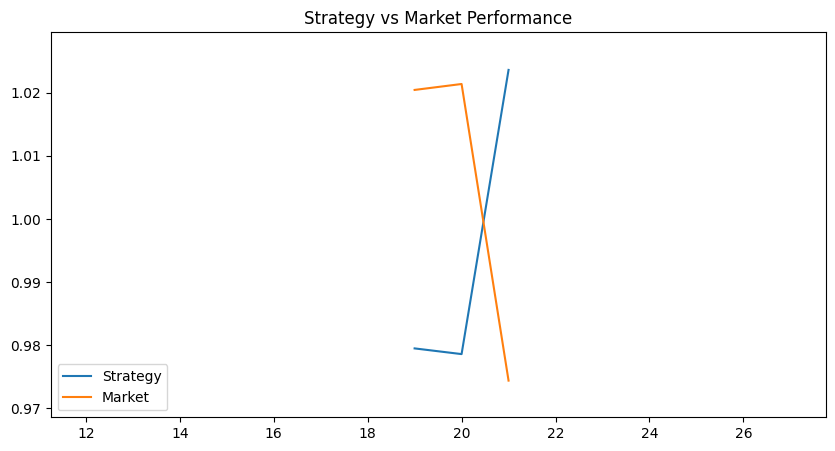

In [161]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(merged_df["cumulative_strategy"], label="Strategy")
plt.plot(merged_df["cumulative_market"], label="Market")

plt.legend()
plt.title("Strategy vs Market Performance")
plt.show()

In [162]:
sharpe = merged_df["strategy_return"].mean() / merged_df["strategy_return"].std()
print("Sharpe Ratio:", sharpe)

Sharpe Ratio: 0.193852742020174


In [163]:
cum = merged_df["cumulative_strategy"]
drawdown = (cum - cum.cummax()) / cum.cummax()

print("Max Drawdown:", drawdown.min())

Max Drawdown: -0.004676751681140128
